# EDA - Eksplorativna analiza svih NLP datasetova

Notebook sluzi za sanity-check predobradenih podataka prije treniranja modela.
Ide redom kroz sva 4 procesirana izvora:

1. **bios_for_embeddings.csv** - sistem preporucivanja
2. **bios_for_topics.csv** - modeliranje tema (icebreakers)
3. **hate_speech_clean.csv** - detekcija govora mrznje
4. **scam_detection_clean.csv** - bot/scam detekcija
5. **sentiment_reviews_clean.csv** + **sentiment_conversations_clean.csv** - sentiment

Prije pokretanja: `python -m src.run_pipeline`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
print('Processed dir:', PROCESSED)
print('Fajlovi:', sorted(p.name for p in PROCESSED.glob('*.csv')))

Processed dir: c:\Users\zerina\Documents\dap\data\processed
Fajlovi: ['hate_speech_clean.csv', 'hate_speech_test.csv', 'hate_speech_train.csv', 'hate_speech_val.csv', 'scam_detection_clean.csv', 'scam_detection_test.csv', 'scam_detection_train.csv', 'scam_detection_val.csv', 'sentiment_conversations_clean.csv', 'sentiment_reviews_clean.csv', 'sentiment_reviews_test.csv', 'sentiment_reviews_train.csv', 'sentiment_reviews_val.csv']


## 1. Bio sekcije (preporuke + topic modeling)

In [3]:
bios = pd.read_csv(PROCESSED / 'bios_for_embeddings.csv')
print(bios.shape)
bios.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\zerina\\Documents\\dap\\data\\processed\\bios_for_embeddings.csv'

In [11]:
bios['n_tokens'] = bios['tokens_str'].fillna('').str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(bios['n_tokens'].clip(upper=400), bins=50, ax=axes[0])
axes[0].set_title('Distribucija duzine bio (tokena, capped 400)')
if 'age' in bios.columns:
    sns.histplot(bios['age'].clip(18, 70), bins=30, ax=axes[1])
    axes[1].set_title('Starost korisnika')
plt.tight_layout()
plt.show()

NameError: name 'bios' is not defined

In [12]:
all_tokens = ' '.join(bios['tokens_str'].dropna().sample(min(5000, len(bios)), random_state=42)).split()
top = Counter(all_tokens).most_common(25)
pd.DataFrame(top, columns=['token', 'freq']).set_index('token').plot.barh(figsize=(8, 7))
plt.title('Top 25 tokena u bio sekcijama')
plt.gca().invert_yaxis()
plt.show()

NameError: name 'bios' is not defined

## 2. Govor mrznje

In [9]:
hate = pd.read_csv(PROCESSED / 'hate_speech_clean.csv')
print(hate.shape)
print(hate['label'].value_counts(normalize=True))
hate.head(3)

(37171, 5)
label
0    0.819402
1    0.180598
Name: proportion, dtype: float64


,text,text_clean,tokens_str,label,source
0,!!! RT @mayasolovely: As a woman you shouldn't...,!! rt <user> : as a woman you should not compl...,rt user woman not complain cleaning house man ...,0,davidson
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,!! rt <user> : boy dats coldtyga dwn bad for c...,rt user boy dat coldtyga dwn bad cuffin dat ho...,0,davidson
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,!! rt <user> dawg!! rt <user> : you ever fuck ...,rt user dawg rt user ever fuck bitch start cry...,0,davidson


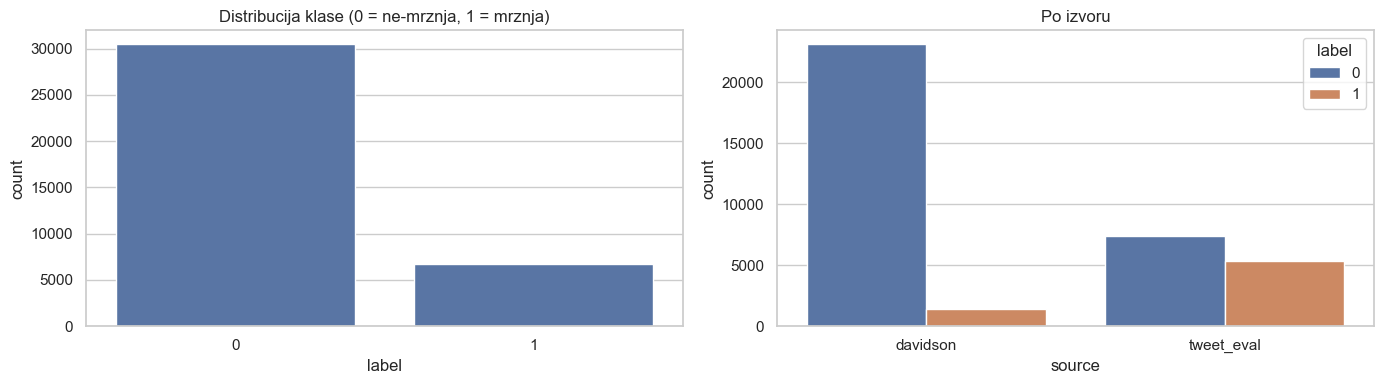

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=hate, x='label', ax=axes[0])
axes[0].set_title('Distribucija klase (0 = ne-mrznja, 1 = mrznja)')
if 'source' in hate.columns:
    sns.countplot(data=hate, x='source', hue='label', ax=axes[1])
    axes[1].set_title('Po izvoru')
plt.tight_layout()
plt.show()

## 3. Detekcija prevara / botova

In [7]:
scam = pd.read_csv(PROCESSED / 'scam_detection_clean.csv')
print(scam.shape)
print(scam.groupby('source')['label'].value_counts())
scam.head(3)

(6806, 10)
source          label
sms_spam        0        4503
                1         605
synthetic_scam  0        1064
                1         634
Name: count, dtype: int64


,text,label,source,text_clean,tokens_str,len_chars,len_tokens,has_url,has_phone,has_money
0,"Go until jurong point, crazy.. Available only ...",0,sms_spam,go until jurong point crazy available only in ...,go jurong point crazy available bugis great wo...,111,14,0,0,0
1,Ok lar... Joking wif u oni...,0,sms_spam,ok lar joking wif you oni,ok lar joking wif oni,29,5,0,0,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,sms_spam,free entry in <NUM> a wkly comp to win fa cup ...,free entry NUM wkly comp win fa cup final tkts...,155,24,0,1,0


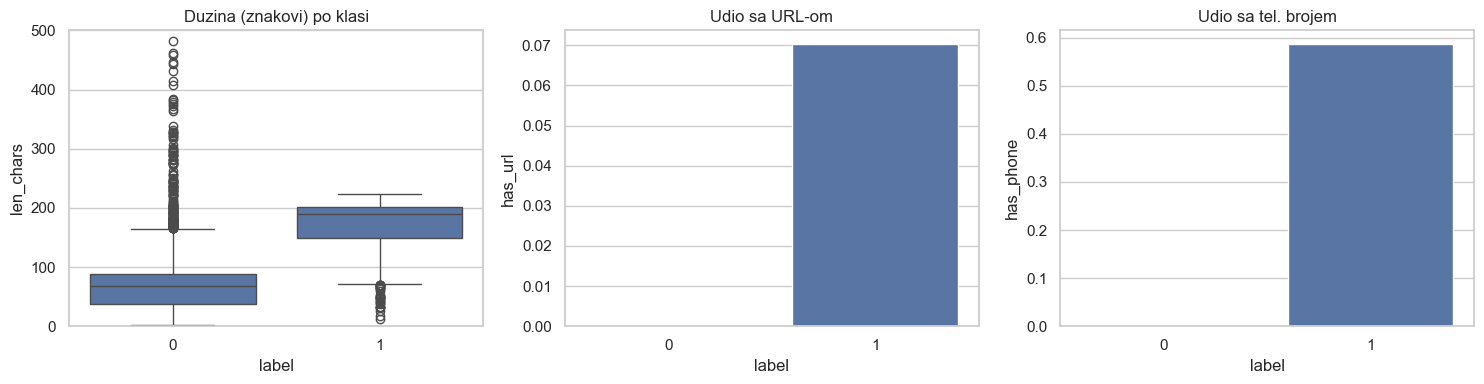

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=scam, x='label', y='len_chars', ax=axes[0])
axes[0].set_title('Duzina (znakovi) po klasi')
axes[0].set_ylim(0, 500)
sns.barplot(data=scam, x='label', y='has_url', ax=axes[1], errorbar=None)
axes[1].set_title('Udio sa URL-om')
sns.barplot(data=scam, x='label', y='has_phone', ax=axes[2], errorbar=None)
axes[2].set_title('Udio sa tel. brojem')
plt.tight_layout()
plt.show()

## 4. Sentiment - recenzije aplikacija

(6198, 6)
sentiment_label
negative    4712
positive    1143
neutral      343
Name: count, dtype: int64


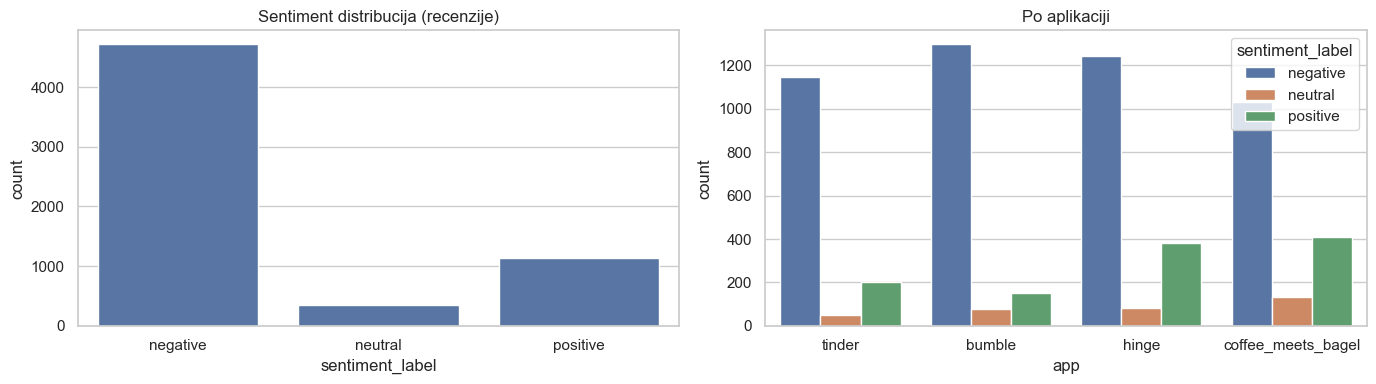

In [6]:
rev_path = PROCESSED / 'sentiment_reviews_clean.csv'
if rev_path.exists():
    rev = pd.read_csv(rev_path)
    print(rev.shape)
    print(rev['sentiment_label'].value_counts())
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.countplot(data=rev, x='sentiment_label', order=['negative', 'neutral', 'positive'], ax=axes[0])
    axes[0].set_title('Sentiment distribucija (recenzije)')
    if 'app' in rev.columns:
        sns.countplot(data=rev, x='app', hue='sentiment_label', ax=axes[1])
        axes[1].set_title('Po aplikaciji')
    plt.tight_layout()
    plt.show()
else:
    print('Recenzije jos nisu skinute - pokreni scrape_tinder_reviews.')

## 5. Sentiment - sinteticki razgovori

(2703, 7)
emotion
interested    458
neutral       456
sarcastic     306
happy         288
bored         157
disengaged    157
playful       153
polite        146
angry         146
frustrated    146
annoyed       146
excited       144
Name: count, dtype: int64


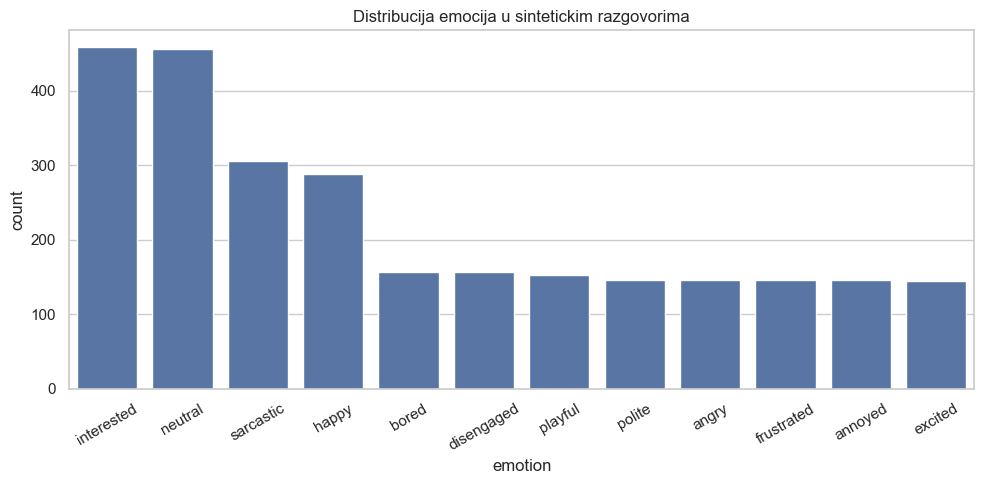

In [5]:
conv_path = PROCESSED / 'sentiment_conversations_clean.csv'
if conv_path.exists():
    conv = pd.read_csv(conv_path)
    print(conv.shape)
    print(conv['emotion'].value_counts())
    sns.countplot(data=conv, x='emotion', order=conv['emotion'].value_counts().index)
    plt.xticks(rotation=30)
    plt.title('Distribucija emocija u sintetickim razgovorima')
    plt.tight_layout()
    plt.show()
else:
    print('Razgovori jos nisu generisani - pokreni generate_synthetic.')